<a href="https://colab.research.google.com/github/sdivyadarshini29-coder/DATA-SCIENCE-INTERNSHIP/blob/main/california_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
data=fetch_california_housing()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target)

In [ ]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target

In [ ]:
print("print first 5 row from the datasets\n",df.head())
print(df.shape)
print(df.info())
print(df.describe())

print first 5 row from the datasets
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4 

In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output Layer (Regression -> 1 neuron, no activation)
model.add(Dense(1))

# Model Summary
print("\nModel Summary:")
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train Model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)



Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1436 - mae: 0.7387 - val_loss: 0.5233 - val_mae: 0.5072
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6054 - mae: 0.5584 - val_loss: 0.4507 - val_mae: 0.4688
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5254 - mae: 0.5169 - val_loss: 0.4325 - val_mae: 0.4520
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4934 - mae: 0.5002 - val_loss: 0.4320 - val_mae: 0.4492
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4743 - mae: 0.4881 - val_loss: 0.4018 - val_mae: 0.4518
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4496 - mae: 0.4761 - val_loss: 0.3959 - val_mae: 0.4367
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4557 - mae: 0.4759 - val_loss: 0.4063 - val_mae: 0.4350
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4412 - mae: 0.4668 - val_loss: 0.3829 - val_mae: 0.4401
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo


Test Loss (MSE): 0.28394824266433716
Test MAE: 0.36424997448921204
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step

Mean Squared Error: 0.2839482891630455
Mean Absolute Error: 0.36424994302093056
R2 Score: 0.7833132297794394


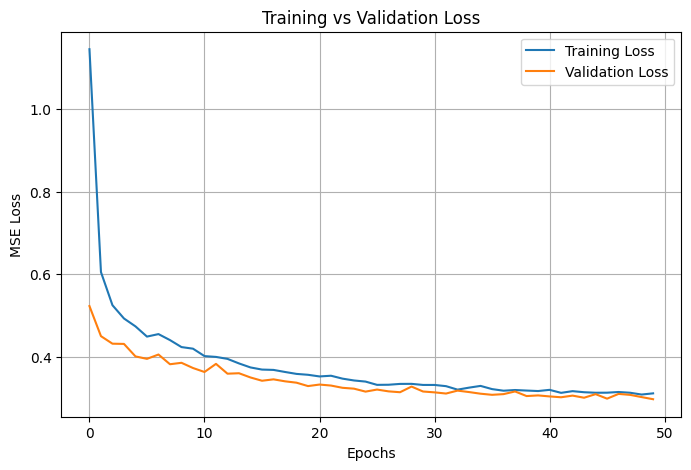

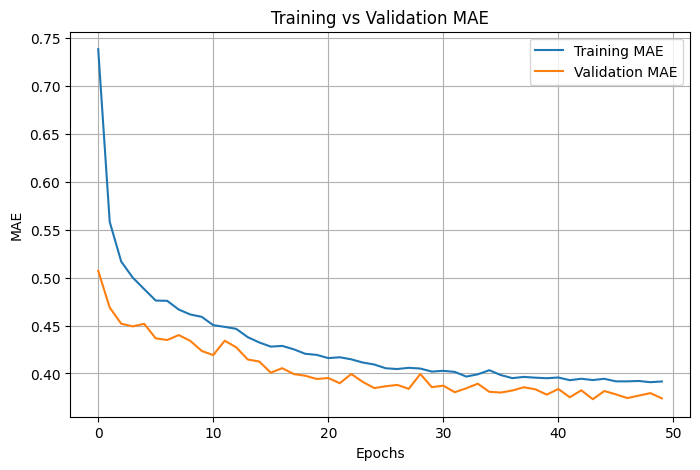

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Single Sample Prediction: 0.6295756
Actual Value: 0.477


In [17]:
loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)

# Predict on Test Data
y_pred = model.predict(X_test_scaled)

# Performance Metrics
print("\nMean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training and Validation MAE
plt.figure(figsize=(8, 5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.show()

# Predict a Single Sample
sample = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)[0][0]

print("\nSingle Sample Prediction:", prediction)
print("Actual Value:", y_test.iloc[0])